<div style="background-color: #000000;
            color: #1E90FF;
            font-weight: bold;
            padding: 22px;
            border-radius: 30px;
            text-align: center;
            font-size: 38px;
            border: 4px ridge #1E90FF;">
BUILDINGS-VS-FORESTS 
    DETECTION
</div>

<div style="background-color: #000000;
            color: #7CFC00;
            font-weight: bold;
            padding: 13px;
            border-radius: 30px;
            text-align: center;
            font-size: 28px;
            border: 4px groove #7CFC00;">
 IMPORT LIBRARIES
</div>

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder 
from tensorflow.keras.utils import to_categorical
import os
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image

<div style="background-color: #000000;
            color: #7CFC00;
            font-weight: bold;
            padding: 13px;
            border-radius: 30px;
            text-align: center;
            font-size: 28px;
            border: 4px groove #7CFC00;">
 ENCODING
</div>

In [2]:
encoder=OneHotEncoder()

In [3]:
encoder.fit([[0],[1]])

OneHotEncoder()

<div style="background-color: #000000;
            color: #7CFC00;
            font-weight: bold;
            padding: 13px;
            border-radius: 30px;
            text-align: center;
            font-size: 28px;
            border: 4px groove #7CFC00;">
 DATASET CREATION
</div>


In [4]:
data=[]
paths=[]
result=[]
for r,d,f in os.walk(r"C:\Users\muhammed shabab\Downloads\archive (2)\buildings-vs-forests\forests\forest"):
    for file in f:
        if'.jpg' or '.jpeg' in file:
            paths.append(os.path.join(r,file))

for path in paths:
    img=Image.open(path)
    img=img.resize((128,128))
    img=np.array(img)
    if(img.shape==(128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[1]]).toarray())

In [5]:
paths=[]
for r,d,f in os.walk(r"C:\Users\muhammed shabab\Downloads\archive (2)\buildings-vs-forests\buildings\buildings"):
    for file in f:
        if '.jpg' in file or '.jpeg' in file:
            paths.append(os.path.join(r,file))

for path in paths:
    img=Image.open(path)
    img=img.resize((128,128))
    img=np.array(img)
    if(img.shape==(128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[0]]).toarray())

In [6]:
data=np.array(data)
data.shape

(5354, 128, 128, 3)

In [7]:
result=np.array(result)
result=result.reshape(5354,2)

<div style="background-color: #000000;
            color: #7CFC00;
            font-weight: bold;
            padding: 13px;
            border-radius: 30px;
            text-align: center;
            font-size: 28px;
            border: 4px groove #7CFC00;">
 VISUALISATIONS
</div>


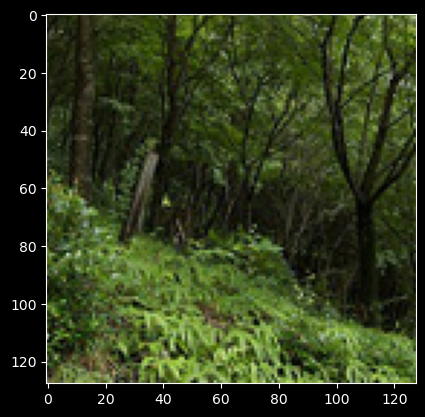

In [8]:
plt.imshow(data[0])

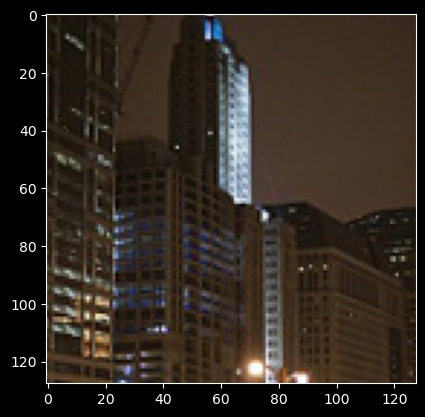

In [9]:
plt.imshow(data[5353])


<div style="background-color: #000000;
            color: #7CFC00;
            font-weight: bold;
            padding: 13px;
            border-radius: 30px;
            text-align: center;
            font-size: 28px;
            border: 4px groove #7CFC00;">
 SPLITTING DATA
</div>


In [10]:
x_train,x_test,y_train,y_test=train_test_split(data,result,test_size=0.2,shuffle=True,random_state=0)

<div style="background-color: #000000;
            color: #7CFC00;
            font-weight: bold;
            padding: 13px;
            border-radius: 30px;
            text-align: center;
            font-size: 28px;
            border: 4px groove #7CFC00;">
 ADDING LAYERS
</div>


In [11]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), input_shape=(128, 128, 3), padding = 'Same'))
model.add(Conv2D(32, kernel_size=(3, 3),  activation ='relu', padding = 'Same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, kernel_size = (3,3), activation ='relu', padding = 'Same'))
model.add(Conv2D(64, kernel_size = (3,3), activation ='relu', padding = 'Same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='sigmoid'))

print(model.summary())

C:\Users\muhammed shabab\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,621,922 (128.26 MB)

 Trainable params: 33,621,730 (128.26 MB)

 Non-trainable params: 192 (768.00 B)

None



<div style="background-color: #000000;
            color: #7CFC00;
            font-weight: bold;
            padding: 13px;
            border-radius: 30px;
            text-align: center;
            font-size: 28px;
            border: 4px groove #7CFC00;">
 COMPILE
</div>


In [12]:
model.compile(loss="binary_crossentropy",optimizer='adam',metrics=['accuracy'])

In [13]:
x_train.shape

(4283, 128, 128, 3)

In [14]:
y_train.shape

(4283, 2)

In [15]:
history=model.fit(x_train,y_train,epochs=20,batch_size=64,verbose=1,validation_data=(x_test,y_test))

Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.8146 - loss: 3.0728 - val_accuracy: 0.8814 - val_loss: 0.4902
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9120 - loss: 0.2879 - val_accuracy: 0.5490 - val_loss: 7.9904
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9276 - loss: 0.2247 - val_accuracy: 0.5285 - val_loss: 13.4229
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9451 - loss: 0.1737 - val_accuracy: 0.5462 - val_loss: 9.1842
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9482 - loss: 0.1588 - val_accuracy: 0.7470 - val_loss: 3.1641
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9563 - loss: 0.1320 - val_accuracy: 0.8357 - val_loss: 1.9132
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9619 - loss: 0.1152 - val_accuracy: 0.8095 - val_loss: 2.1209
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9629 - loss: 0.1224 - val_accuracy: 0.5490 - val_loss

In [16]:
score=model.evaluate(x_test,y_test,batch_size=64)
print(f"\nTest accuracy: {100.0 * score[1]:.1f}%")

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.8534 - loss: 1.8253

Test accuracy: 85.3%



<div style="background-color: #000000;
            color: #7CFC00;
            font-weight: bold;
            padding: 13px;
            border-radius: 30px;
            text-align: center;
            font-size: 28px;
            border: 4px groove #7CFC00;">
 PREDICTION
</div>


In [17]:

img = image.load_img(
    r"C:\Users\muhammed shabab\Downloads\archive (2)\buildings-vs-forests\buildings\buildings\18072.jpg",
    target_size=(128, 128) 
)

img_array =np.array(img)

img_array = img_array.reshape(1, 128, 128, 3)

print(img_array.shape) 

(1, 128, 128, 3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


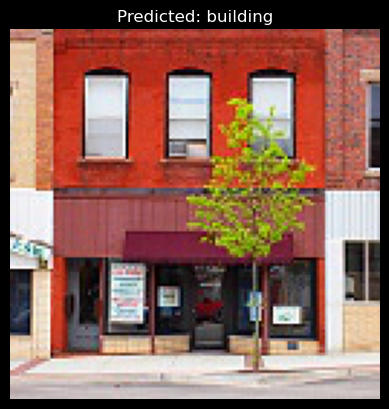

Predicted class: building


In [19]:
class_names = ['building','forest']

prediction = model.predict(img_array)
predicted_index = np.argmax(prediction)
predicted_label = class_names[predicted_index]

plt.imshow(img)
plt.title("Predicted: " + predicted_label)
plt.axis('off')   
plt.show()

print("Predicted class:", predicted_label)